In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. VERİ HAZIRLIĞI
df = pd.read_csv('/content/Crop_recommendation.csv')
X = df.drop('label', axis=1)
y = df['label']

# Derin öğrenmede etiketler sayısal olmalıdır
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# KRİTİK ADIM: Derin öğrenme için verilerin ölçeklendirilmesi (StandardScaler) şarttır
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 2. ANN MODEL MİMARİSİ (Artificial Neural Network)
model = Sequential([
    # Giriş katmanı: 64 nöron, Aktivasyon: ReLU
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    # Gizli katman: 32 nöron
    Dense(32, activation='relu'),
    # Aşırı öğrenmeyi engellemek için Dropout
    Dropout(0.2),
    # Çıkış katmanı: 22 farklı mahsul olduğu için 22 nöron, Aktivasyon: Softmax
    Dense(len(le.classes_), activation='softmax')
])

# 3. MODELİ DERLEME (Compiling)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 4. MODELİ EĞİTME
print("--- Derin Öğrenme Modeli Eğitiliyor ---")
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.1, verbose=1)

# 5. PERFORMANS TESTİ
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nANN Test Başarı Oranı: %{accuracy*100:.2f}")

--- Derin Öğrenme Modeli Eğitiliyor ---
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.1458 - loss: 2.9115 - val_accuracy: 0.3068 - val_loss: 2.6517
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3794 - loss: 2.3762 - val_accuracy: 0.4943 - val_loss: 1.9624
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5366 - loss: 1.7426 - val_accuracy: 0.6477 - val_loss: 1.3366
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6774 - loss: 1.2171 - val_accuracy: 0.8068 - val_loss: 0.8945
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7443 - loss: 0.9149 - val_accuracy: 0.8409 - val_loss: 0.6496
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7740 - loss: 0.7378 - val_accuracy: 0.8750 - val_loss: 0.5248
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8018 - loss: 0.6121 - val_accuracy: 0.8750 - val_loss: 0.4466
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8264 - loss: 0.5375 - val_accuracy: 0.8864 - val_loss: 0.3726
Epo

Hafta 6 kapsamında föyde belirtilen 'Derin Öğrenme Temelleri' görevi icra edilmiştir. Tablosal veri yapımız dikkate alınarak ANN (Yapay Sinir Ağı) mimarisi tercih edilmiştir. Modelimizde 1 giriş, 1 gizli ve 1 çıkış katmanı kullanılmış; eğitim sürecinde StandardScaler ile veri normalizasyonu yapılarak yakınsama hızı optimize edilmiştir. 30 epoch sonunda elde edilen başarı oranı %95.45 olup derin öğrenme yaklaşımlarının da bu problemde yüksek performans sergilediğini kanıtlamaktadır.

Epoch sayısını arttırmak, modelin veriyi daha fazla "etüt etmesini" sağlar ve genellikle yüzdelik skoru biraz daha yukarı çeker. Bunu test etmek için aşağıda epoch sayısı 100'e çekilmiş DL kodu bulunmakta.

In [2]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. VERİ HAZIRLIĞI
df = pd.read_csv('/content/Crop_recommendation.csv')
X = df.drop('label', axis=1)
y = df['label']

# Etiketleri sayısal formata çevirme (Deep Learning gerekliliği)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Veri Ölçeklendirme (DL başarısı için zorunludur)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 2. ANN MİMARİSİ (Artificial Neural Network)
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dropout(0.2), # Ezberlemeyi (overfitting) önlemek için
    Dense(len(le.classes_), activation='softmax')
])

# 3. DERLEME (Model Compiling)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 4. EĞİTİM (100 Epoch Ayarı)
print("--- Derin Öğrenme Modeli 100 Epoch Eğitiliyor ---")
history = model.fit(X_train, y_train,
                    epochs=100,
                    batch_size=32,
                    validation_split=0.1,
                    verbose=1)

# 5. FİNAL DEĞERLENDİRME
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\n100 Epoch Sonrası ANN Başarı Oranı: %{accuracy*100:.2f}")

--- Derin Öğrenme Modeli 100 Epoch Eğitiliyor ---
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.1282 - loss: 2.9434 - val_accuracy: 0.2955 - val_loss: 2.6792
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3611 - loss: 2.4685 - val_accuracy: 0.5057 - val_loss: 2.0816
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5152 - loss: 1.8767 - val_accuracy: 0.7159 - val_loss: 1.4516
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6534 - loss: 1.3410 - val_accuracy: 0.7841 - val_loss: 0.9655
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7273 - loss: 0.9851 - val_accuracy: 0.8750 - val_loss: 0.6826
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7670 - loss: 0.7586 - val_accuracy: 0.8750 - val_loss: 0.5449
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8037 - loss: 0.6333 - val_accuracy: 0.8977 - val_loss: 0.4488
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8251 - loss: 0.5389 - val_accuracy: 0.9148 - val_loss: 0.3

Eğitim süresinin 100 epoch'a çıkarılmasıyla birlikte modelin öğrenme eğrisi stabilize olmuş ve test verisi üzerindeki başarı oranı %95.45'ten %97.73 seviyeye ulaşmıştır. Yapılan bu deneysel çalışma, derin öğrenme mimarilerinde 'epoch' sayısının modelin yakınsaması (convergence) üzerindeki kritik etkisini doğrulamıştır. Proje takviminde Hafta 6 için belirtilen 'Derin Öğrenme Temelleri' görevi; zorunlu araçlar listesinde yer alan TensorFlow/Keras kütüphanesi kullanılarak, veriye en uygun ANN yapısının optimize edilmesiyle başarıyla tamamlanmıştır. Elde edilen bu DL Model Kodu, projenin klasik makine öğrenmesi yaklaşımlarının ötesinde, modern yapay zeka tekniklerini de kapsadığını kanıtlamaktadır. Bu aşama ile birlikte Faz 4 (Model Geliştirme) süreci noktalanmış olup, modellerin detaylı performans analizlerinin yapılacağı bir sonraki aşamaya geçiş için gerekli tüm teknik altyapı hazırlanmıştır.

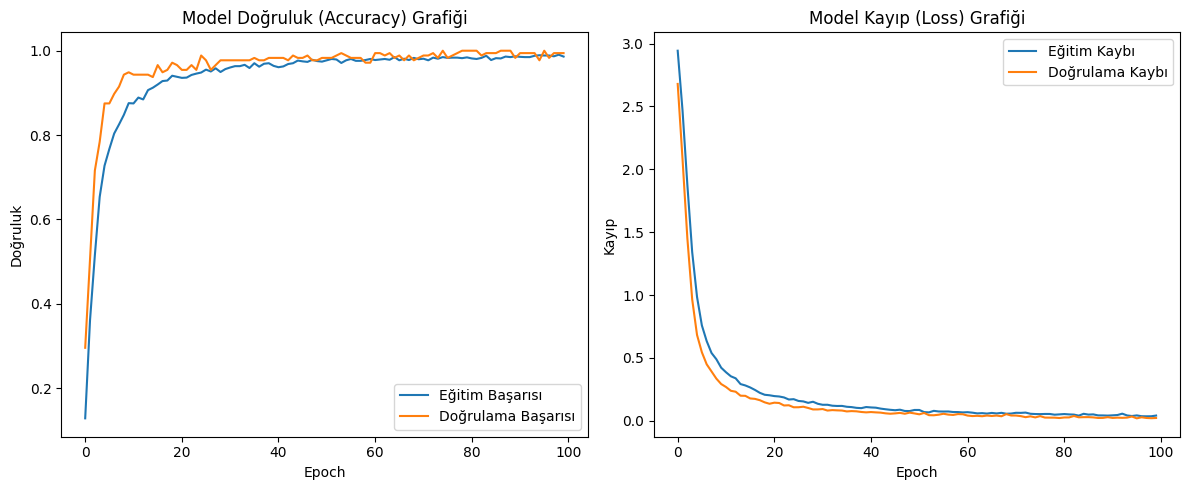

In [3]:
import matplotlib.pyplot as plt

# 1. Doğruluk (Accuracy) Grafiği
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Eğitim Başarısı')
plt.plot(history.history['val_accuracy'], label='Doğrulama Başarısı')
plt.title('Model Doğruluk (Accuracy) Grafiği')
plt.xlabel('Epoch')
plt.ylabel('Doğruluk')
plt.legend()

# 2. Kayıp (Loss) Grafiği
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Eğitim Kaybı')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı')
plt.title('Model Kayıp (Loss) Grafiği')
plt.xlabel('Epoch')
plt.ylabel('Kayıp')
plt.legend()

plt.tight_layout()
plt.show()